# CAPM Model

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **CAPM and Fama–French Models** and contains the computational implementation supporting the methodology, experiments, and results discussed in the portfolio chapter.

The material presented here focuses on practical implementation details, including data preparation, model development, training procedures, evaluation workflows, and complementary computational experiments.

## Imports and Configuration

This section initializes the main libraries used throughout the notebook.

The analysis uses historical market data obtained from Yahoo Finance together with standard Python libraries for data manipulation, visualization, and linear regression modeling.

The goal is to evaluate a simple CAPM specification by comparing the returns of an individual asset against the S&P 500 index as a proxy for the overall market.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Financial data
import yfinance as yf

# Statistical modeling
import statsmodels.api as sm

# Plot configuration
plt.style.use("default")
pd.options.display.float_format = "{:.4f}".format

## Asset Selection and Market Benchmark

Apple Inc. (`AAPL`) is used as the individual asset, while the S&P 500 index (`^GSPC`) is used as a proxy for the market portfolio.

The analysis uses five years of daily adjusted closing prices obtained from Yahoo Finance.

In [2]:
# Asset and benchmark tickers
asset_ticker = "AAPL"
market_ticker = "^GSPC"

# Time window
start_date = "2020-01-01"
end_date = "2024-12-31"

## Data Collection

Daily closing prices for both the selected asset and the market index are downloaded from Yahoo Finance and combined into a single dataset for further analysis.

The downloaded prices are adjusted for corporate actions when available, making them suitable for return calculation.

In [3]:
# Download price data
tickers = [asset_ticker, market_ticker]

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

# Select closing prices
prices = data["Close"].copy()

# Rename columns
prices = prices.rename(columns={
    asset_ticker: "asset",
    market_ticker: "market"
})

# Remove missing values
prices = prices.dropna()

prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,asset,market
Date,,
2020-01-02,72.3339,3257.8501
2020-01-03,71.6306,3234.8501
2020-01-06,72.2014,3246.2800
2020-01-07,71.8618,3237.1799
2020-01-08,73.0178,3253.0500


## Price Series Visualization

The price series are inspected before computing returns. Since the asset and the market index are expressed on different price scales, this plot is mainly used as a quick check of the downloaded data.

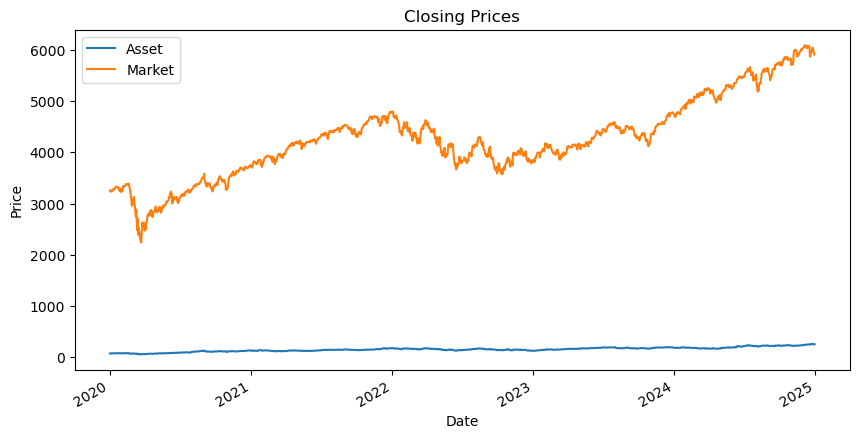

In [4]:
# Plot price series
prices.plot(figsize=(10, 5))

plt.title("Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(["Asset", "Market"])

plt.show()

## Return Calculation

Daily returns are computed from the adjusted closing price series and used as the main variables in the CAPM regression analysis.

These returns provide a normalized representation of market behavior and allow the linear relationship between the asset and the market portfolio to be estimated.

In [5]:
# Compute daily returns
returns = prices.pct_change()

# Remove missing values
returns = returns.dropna()

returns.head()

Ticker,asset,market
Date,,
2020-01-03,-0.0097,-0.0071
2020-01-06,0.0080,0.0035
2020-01-07,-0.0047,-0.0028
2020-01-08,0.0161,0.0049
2020-01-09,0.0212,0.0067


## Exploratory Analysis

The relationship between asset and market returns is briefly explored before estimating the regression model.

The scatter plot provides an initial visual assessment of the linear association assumed by the CAPM framework.

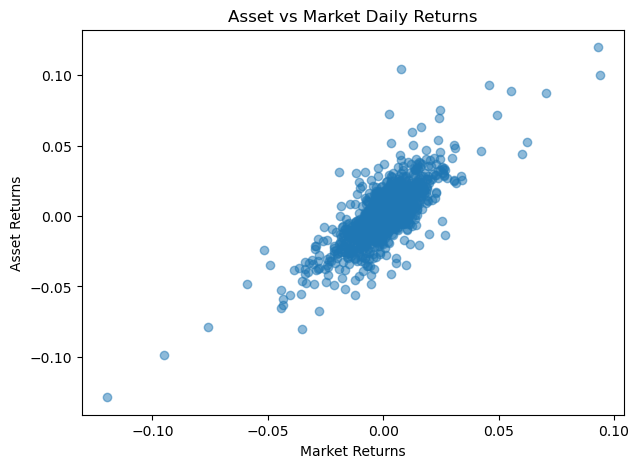

In [6]:
# Scatter plot of daily returns
plt.figure(figsize=(7, 5))

plt.scatter(
    returns["market"],
    returns["asset"],
    alpha=0.5
)

plt.xlabel("Market Returns")
plt.ylabel("Asset Returns")
plt.title("Asset vs Market Daily Returns")

plt.show()

## CAPM Estimation

A simple linear regression is estimated using market returns as the independent variable and asset returns as the dependent variable.

The estimated coefficients are interpreted as the asset alpha and beta under the CAPM specification.

In [7]:
# Define independent and dependent variables
X = returns["market"]
y = returns["asset"]

# Add intercept term
X = sm.add_constant(X)

# Fit linear regression model
capm_model = sm.OLS(y, X).fit()

# Display regression summary
print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     2087.
Date:                Sun, 24 May 2026   Prob (F-statistic):          4.07e-269
Time:                        22:41:37   Log-Likelihood:                 3749.6
No. Observations:                1256   AIC:                            -7495.
Df Residuals:                    1254   BIC:                            -7485.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.523      0.1

## Model Evaluation

The estimated regression coefficients are inspected together with the fitted relationship between asset and market returns.

The regression line provides a visual representation of the sensitivity of the selected asset to movements in the market portfolio.

In [8]:
# Extract regression coefficients
alpha = capm_model.params["const"]
beta = capm_model.params["market"]

print(f"Alpha: {alpha:.6f}")
print(f"Beta: {beta:.4f}")

Alpha: 0.000526
Beta: 1.1733


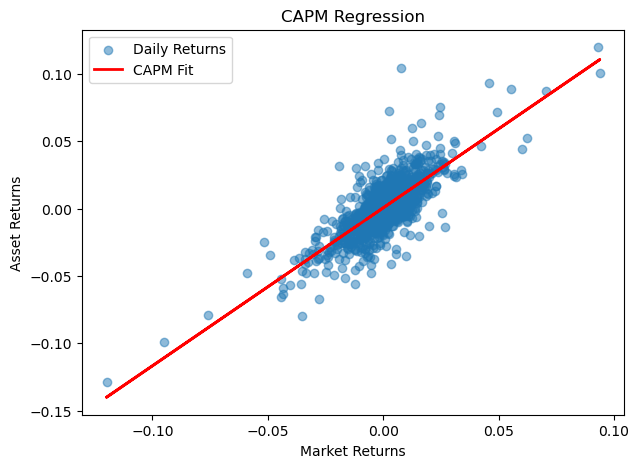

In [9]:
# Scatter plot with regression line
plt.figure(figsize=(7, 5))

# Scatter points
plt.scatter(
    returns["market"],
    returns["asset"],
    alpha=0.5,
    label="Daily Returns"
)

# Regression line
plt.plot(
    returns["market"],
    capm_model.predict(X),
    color="red",
    linewidth=2,
    label="CAPM Fit"
)

plt.xlabel("Market Returns")
plt.ylabel("Asset Returns")
plt.title("CAPM Regression")

plt.legend()

plt.show()